In [1]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
import matplotlib.gridspec as gridspec  
from matplotlib import rcParams  
from matplotlib.ticker import MaxNLocator  
import seaborn as sns  
import os  

# Set up matplotlib parameters to match Cell paper style  
rcParams['font.family'] = 'sans-serif'  
rcParams['font.sans-serif'] = ['Arial']  
rcParams['font.size'] = 10 
rcParams['axes.linewidth'] = 0.8  
rcParams['xtick.major.width'] = 0.8  
rcParams['ytick.major.width'] = 0.8  
rcParams['xtick.major.size'] = 3  
rcParams['ytick.major.size'] = 3  
rcParams['pdf.fonttype'] = 42  # Ensures text is editable in AI  
rcParams['ps.fonttype'] = 42  
rcParams['svg.fonttype'] = 'none'  
rcParams['figure.dpi'] = 300  

# Cell paper color palette  
cell_blue = "#3C5488FF"
cell_orange = "#f9a65a"  
cell_text = "k"  
cell_gray = "#bbb"  



In [11]:
df_select= pd.read_csv('neuron_up_inframe_miniexon_conserved.csv')


In [12]:
df_phase = pd.read_csv('./PICNIC-9606-data.csv',header = 0)
df_phase['Genes'] = [str(i).split(' ')[0] for i in df_phase['Genes']]
df_merge = df_select.merge(df_phase, left_on='GENE', right_on = 'Genes')


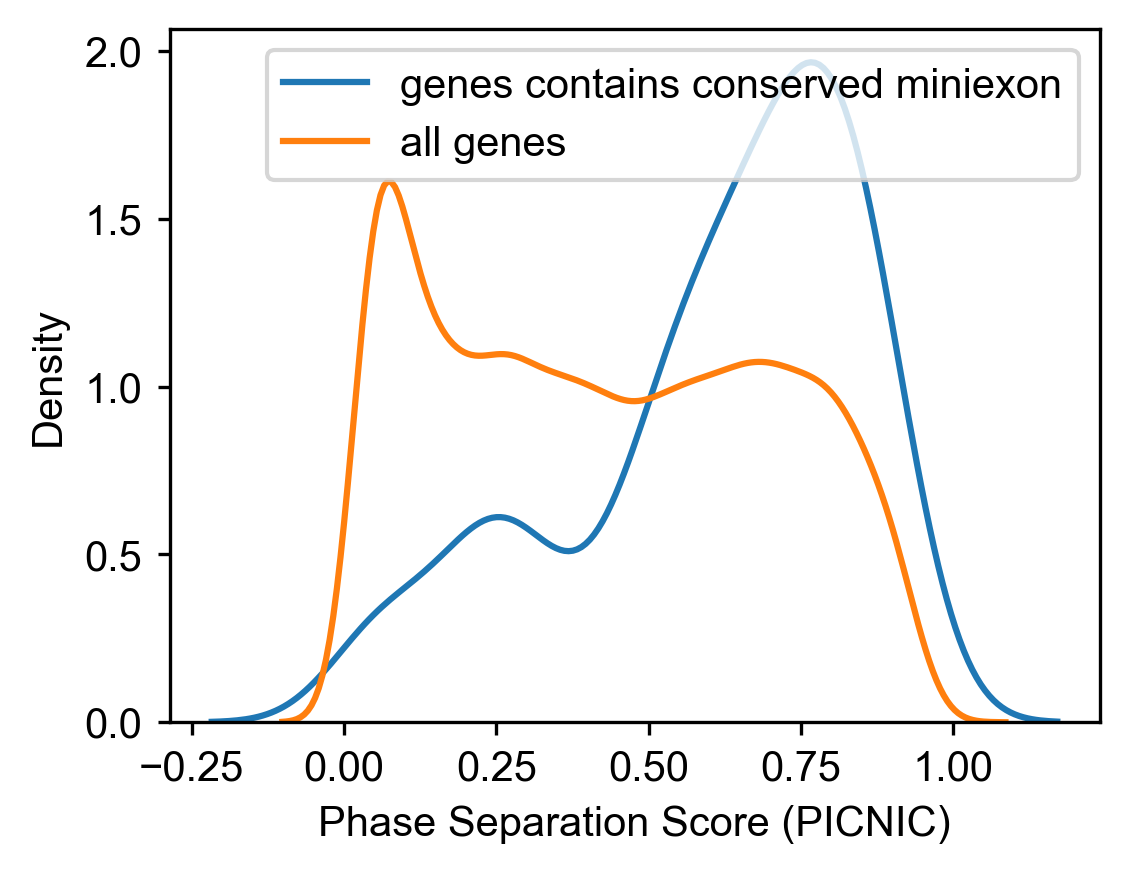

In [17]:
plt.figure(figsize = [4,3])
# sns.kdeplot(df_merge.drop_duplicates('GENE')['PICNIC score'], 
#             label = 'genes contains conserved miniexon all')
sns.kdeplot(df_merge[df_merge['LENGTH']<=90].drop_duplicates('GENE')['PICNIC score'], 
            label = 'genes contains conserved miniexon')
# sns.kdeplot(df_merge[df_merge['LENGTH']<=30].drop_duplicates('GENE')['PICNIC score'], 
#             label = 'genes contains conserved miniexon <= 30nt')
sns.kdeplot(df_phase['PICNIC score'], label = 'all genes')
plt.legend()
plt.xlabel('Phase Separation Score (PICNIC)')
plt.savefig('PICNIC_score_miniexon.pdf')

In [18]:
df_php = pd.read_table('./AllhumanReviewed.txt')

In [19]:
df_s = df_php[df_php['Gene'].isin(df_select['GENE'])]

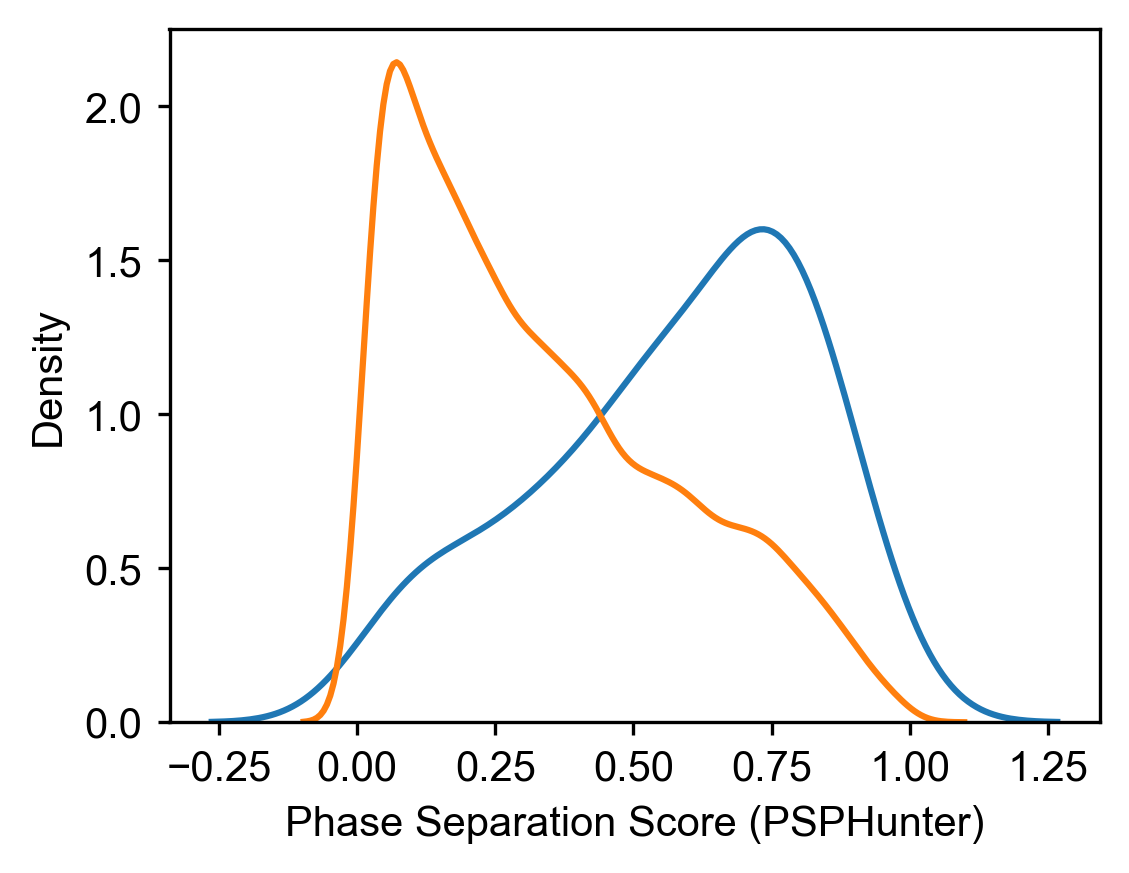

In [20]:
plt.figure(figsize = [4,3])
sns.kdeplot(df_s['Probability'], label = 'genes contains miniexon')
sns.kdeplot(df_php['Probability'], label = 'all genes')
plt.xlabel('Phase Separation Score (PSPHunter)')
plt.savefig('./PHPhunter_score.pdf')